## Import libraries

In [43]:
import os
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


## Load and Preprocess Data

In [44]:
def load_data(file_path="data/processed/df_clean.csv"):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Could not find file at: {file_path}")

    df = pd.read_csv(file_path)

    expected_cols = {"division", "date", "zhvi", "hpi", "unemployment_rate"}
    missing = expected_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing expected columns: {missing}")
    

    return df


def preprocess_data(df):
    df = df.copy()

    # Drop duplicate
    df = df.drop_duplicates(subset=['division', 'date']).reset_index(drop=True)

    # Date and Sort
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["division", "date"]).reset_index(drop=True)
    
    # List of all new numerical features
    numeric_features = [
        "hpi", "unemployment_rate", "total_population", "median_income", 
        "bachelors_pct", "total_households", "construction_permits", "rental_vacancy_rate"
    ]
    
    
    # Drop any rows where numeric features 
    df = df.dropna(subset=numeric_features).reset_index(drop=True)
    
    
    # Time and Month Index
    min_date = df["date"].min()
    df["time_index"] = (
        (df["date"].dt.year - min_date.year) * 12
        + (df["date"].dt.month - min_date.month)
    )
    df["month"] = df["date"].dt.month.astype(str)

    df_model = pd.get_dummies(df, columns=["division", "month"], drop_first=True)
    
    return df, df_model

## Split data into train and test based on the date

In [45]:
def time_train_test_split(df_raw, df_model, split_ratio=0.8):
    unique_dates = sorted(df_raw["date"].unique())
    split_idx = int(len(unique_dates) * split_ratio)
    split_date = unique_dates[split_idx]

    train_mask = df_model["date"] < split_date
    test_mask = df_model["date"] >= split_date

    train_df = df_model.loc[train_mask].copy()
    test_df = df_model.loc[test_mask].copy()

    return train_df, test_df, split_date


def build_features(train_df, test_df):
    target = "zhvi"
    drop_cols = ["zhvi", "date"]
    feature_cols = [col for col in train_df.columns if col not in drop_cols]

    X_train = train_df[feature_cols]
    y_train = train_df[target]
    X_test = test_df[feature_cols]
    y_test = test_df[target]

    # Scale the data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, feature_cols


def train_model(X_train, y_train, model_type="linear", alpha=1.0):
    if model_type == "linear":
        model = LinearRegression()
    elif model_type == "ridge":
        model = Ridge(alpha=alpha)
    elif model_type == "rf":
        model = RandomForestRegressor(n_estimators=100, random_state=42)
    else:
        raise ValueError("Unsupported model type")
        
    model.fit(X_train, y_train)
    return model


def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    metrics = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

    return y_pred, metrics


## Get Results

Loading cleaned dataset...
Preprocessing data...
Original cleaned shape: (1620, 11)
Model-ready shape: (1620, 30)
Creating time-based train/test split...
Train/Test split date: 2022-01-01
Building features...

--- Training Linear_Regression ---


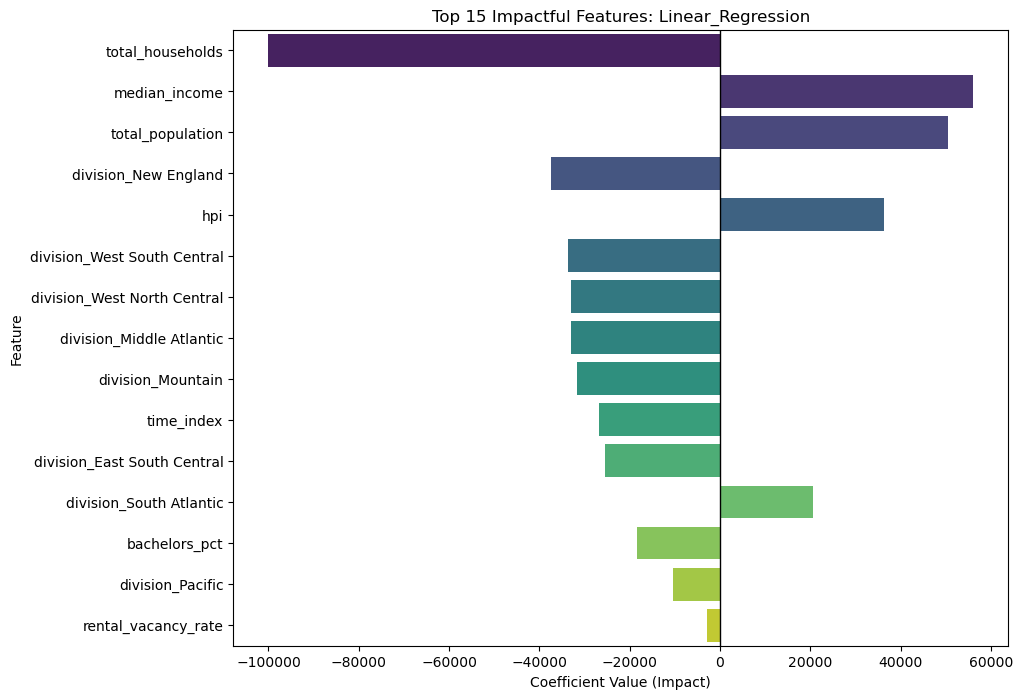


--- Training Ridge_Regression ---


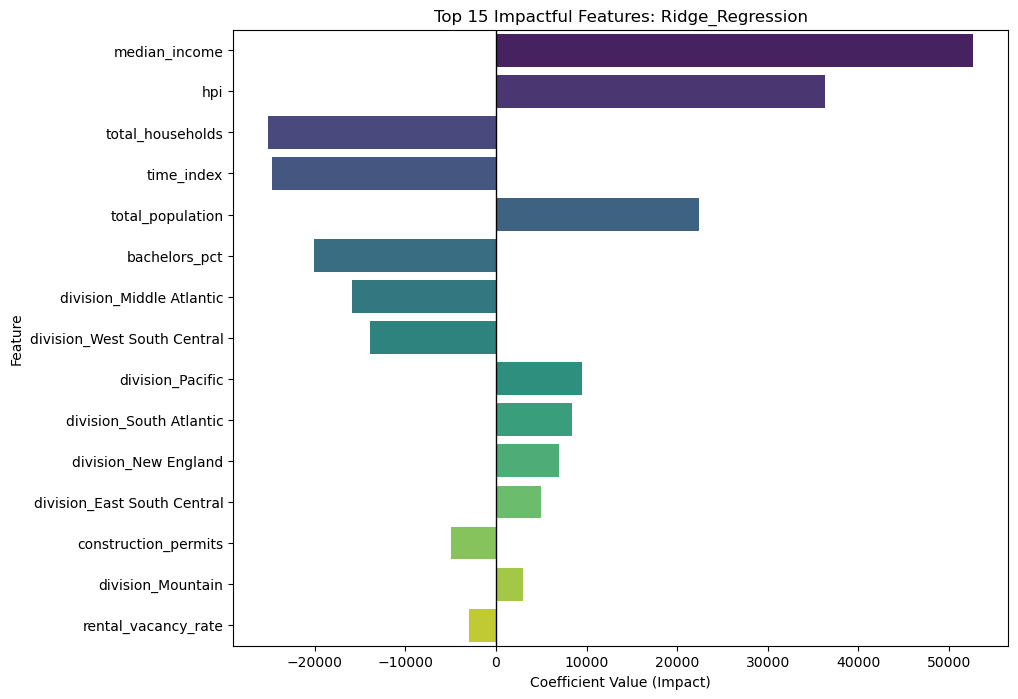


--- Training Random_Forest ---


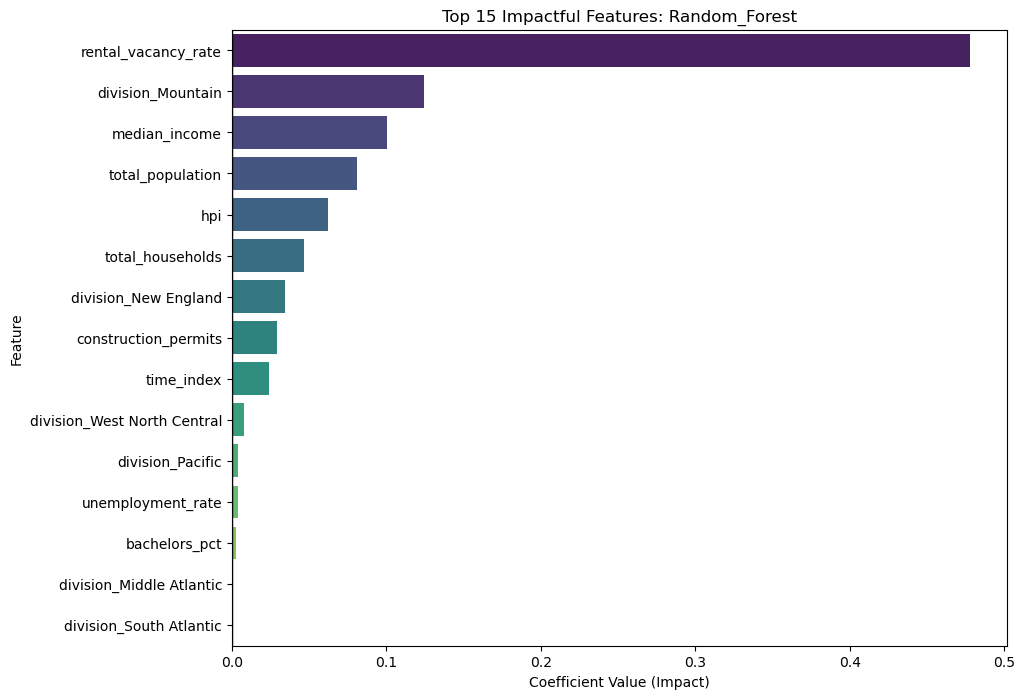


--- FINAL MODEL COMPARISON ---
                            MAE          RMSE        R2
Model                                                  
Linear_Regression  31074.184362  34573.926419  0.914958
Ridge_Regression   34221.878020  37664.903589  0.899072
Random_Forest      47502.020783  79879.954669  0.546046


In [46]:
def save_outputs(test_df_raw, y_test, y_pred, feature_cols, model, model_name="model"):
    os.makedirs("outputs", exist_ok=True)

    # Create a results df using the unscaled test data
    results = test_df_raw.copy()
    results["actual_zhvi"] = y_test.values
    results["predicted_zhvi"] = y_pred

    # Get the division name
    division_cols = [c for c in results.columns if c.startswith('division_')]
    
    def get_division(row):
        for col in division_cols:
            if row[col] == 1:
                return col.replace('division_', '')
        return 'East_North_Central' 
    
    results['division_name'] = results.apply(get_division, axis=1)

    # Filter the columns 
    final_output = results[['date', 'division_name', 'actual_zhvi', 'predicted_zhvi']]
    final_output.to_csv(f"outputs/{model_name}_predictions.csv", index=False)

    if hasattr(model, 'coef_'):
        values = model.coef_
    else:
        values = model.feature_importances_

    # Save unique coefficients file
    coef_df = pd.DataFrame({
        "feature": feature_cols,
        "value": values
    }).sort_values("value", key=abs, ascending=False)

    coef_df.to_csv(f"outputs/{model_name}_coefficients.csv", index=False)

    return coef_df

BASE_DATA_PATH = "data/processed/df_clean_with_all_features_model_ready_2010_2024.csv"

import matplotlib.pyplot as plt
import seaborn as sns

def plot_coefficients(coef_df, model_name):
    plt.figure(figsize=(10, 8))
    # Take the top 15
    top_15 = coef_df.head(15).copy()
    
    # Use seaborn for a clean look
    sns.barplot(x='value', y='feature', data=top_15, palette='viridis')
    
    plt.title(f'Top 15 Impactful Features: {model_name}')
    plt.xlabel('Coefficient Value (Impact)')
    plt.ylabel('Feature')
    plt.axvline(0, color='black', lw=1) # Add a line at zero
    plt.show()

def main():
    print("Loading cleaned dataset...")
    df = load_data(BASE_DATA_PATH)

    print("Preprocessing data...")
    df_raw, df_model = preprocess_data(df)

    print(f"Original cleaned shape: {df.shape}")
    print(f"Model-ready shape: {df_model.shape}")

    print("Creating time-based train/test split...")
    # Splits into training (pre-2022) and testing (post-2022)
    train_df, test_df, split_date = time_train_test_split(df_raw, df_model, split_ratio=0.8)
    print(f"Train/Test split date: {pd.to_datetime(split_date).date()}")

    print("Building features...")
    # Handles scaling and returns the final feature list
    X_train, X_test, y_train, y_test, feature_cols = build_features(train_df, test_df)

    model_configs = [
        {"name": "Linear_Regression", "type": "linear", "alpha": None},
        {"name": "Ridge_Regression", "type": "ridge", "alpha": 1.0},
        {"name": "Random_Forest", "type": "rf", "alpha": None}
    ]

    all_results = []

    for config in model_configs:
        print(f"\n--- Training {config['name']} ---")
        
        # 1. Train
        model = train_model(X_train, y_train, model_type=config['type'], alpha=config['alpha'])
        
        # 2. Evaluate
        y_pred, metrics = evaluate_model(model, X_test, y_test)
        metrics['Model'] = config['name']
        all_results.append(metrics)
        
        # 3. Save and Plot
        coef_df = save_outputs(test_df, y_test, y_pred, feature_cols, model, model_name=config['name'])
        
        plot_coefficients(coef_df, config['name'])
        

    # Comparison results between models
    comparison_df = pd.DataFrame(all_results).set_index('Model')
    print("\n--- FINAL MODEL COMPARISON ---")
    print(comparison_df)

if __name__ == "__main__":
    main()

## Justifications for Features and Models

Features:
- hpi (Home Price Index): Provides broader context into the housing market 
- Unemployment Rate: Higher unemployment means less buyers, while lower unemployments means more buyers
- Median Income: How much the avergae region can afford to buy
- Total Population & Total Households: Can represent the demand for housing
- Construction Permits: How much supply is there for homes
- Rental Vacancy Rate: Low vacancy rates suggest a shortage of housing, forcing people toward homeownership and driving up ZHVI
- Bachelors Percantage: Level of education and high or low paying jobs
- Division: Price in location varies
- Month: Capture potential seasonal patterns
- Time Index: Provide capturing long term movement


Models:
- Multiple Linear Regression: Establish a baseline of interpretability, allowing us to quantify the direct relationship between economic indicators and housing value.
- Ridge Regression: Some of our feautres are multicollinear (e.g. Median Income and Bachelors Percentage). Linear regression can overfit when features are too similar. Using the L2 penalty of ridge can improve stability and generalizing new unseen data.
- Random Forest: To capture non-linear relationships and complex interactions between variables that traditional linear models might overlook (e.g. how region/location may affect the impact of unemployment.)

## Results & Interpretation

### Coefficients

The coefficient analysis across all three models reveals that U.S. home values are primarily driven by broad economic fundamentals, while local supply constraints create additional pricing pressure. In both the Linear and Ridge Regression models, Median Income emerged as the strongest positive predictor, showing that household purchasing power is one of the most reliable determinants of housing prices. Home Price Index (HPI) and Total Population were also major positive contributors, reinforcing the idea that stronger markets and higher demand lead to higher home values. Ridge Regression largely confirmed the same relationships while shrinking unstable coefficients, making it a more reliable version of the linear model. Some variables, such as Total Households and Bachelor’s Degree Percentage, had negative coefficients, likely due to multicollinearity and overlap with stronger variables like income and population rather than true negative economic effects. In contrast, the Random Forest model highlighted a different perspective. Rental Vacancy Rate was by far the most important feature, accounting for 47.7% of the model’s predictive importance. This suggests that low housing supply and limited availability can cause sudden increases in home prices that linear models may not fully capture. The Random Forest also identified the Mountain Division as a key regional hotspot, likely reflecting recent migration-driven growth. Across all models, seasonality variables such as month of the year had minimal impact. Overall, the results suggest that income and demand establish the baseline value of homes, while limited supply drives price surges.

### Metrics
The final model comparison shows that the Linear Regression model performed the best overall, achieving the lowest prediction errors and the highest explanatory power. It produced a Mean Absolute Error (MAE) of approximately \$31,074, meaning its predictions were off by about \$31,000 on average, and a Root Mean Squared Error (RMSE) of \$34,574. Most importantly, it achieved an $R^2$ score of 0.915, meaning the model explained roughly 91.5% of the variation in regional home values. This strong performance suggests that housing prices in the dataset were largely driven by stable, linear relationships with the economic indicators used.

The Ridge Regression model performed slightly worse than standard Linear Regression, with an MAE of \$34,222, RMSE of \$37,665, and $R^2$ of 0.899. Although its predictive accuracy was slightly lower, Ridge Regression remains valuable because it reduces coefficient instability caused by correlated variables. In other words, it sacrifices a small amount of accuracy in exchange for a more robust and reliable model structure.

The Random Forest model had the weakest performance, with the highest error MAE of \$47,502 and RMSE of \$79,880, and a significantly lower $R^2$ of 0.546. This means it explained only about 54.6% of the variation in home values, far below the linear models. A reason for this is that Random Forest cannot predict values outside of its training set. Since we trained on data from 2010-2021, and tested on data 2022-2024. Random Forest may not be able to predict higher values typically seen in the later period of times. While Random Forest is capable of modeling complex non-linear patterns, these results indicate that the housing market in this project was better explained by broad economic trends than by localized non-linear interactions. Overall, the metrics demonstrate that simpler linear models were the most effective tools for predicting regional home values in this dataset.
